<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" height=300 width=300 />


# Final Project: League of Legends Match Predictor 


### Introduction  

League of Legends, a popular multiplayer online battle arena (MOBA) game, generates extensive data from matches, providing an excellent opportunity to apply machine learning techniques to real-world scenarios. Perform the following steps to build a logistic regression model aimed at predicting the outcomes of League of Legends matches.  

Use the [league_of_legends_data_large.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rk7VDaPjMp1h5VXS-cUyMg/league-of-legends-data-large.csv) file to perform the tasks.  

### Step 1: Data Loading and Preprocessing  

#### Task 1: Load the League of Legends dataset and preprocess it for training.  

Loading and preprocessing the dataset involves reading the data, splitting it into training and testing sets, and standardizing the features. You will utilize `pandas` for data manipulation, `train_test_split` from `sklearn` for data splitting, and `StandardScaler` for feature scaling.  

Note: Please ensure all the required libraries are installed and imported.

1 .Load the dataset:
Use `pd.read_csv()` to load the dataset into a pandas DataFrame.</br>
2. Split data into features and target: Separate win (target) and the remaining columns (features).</br>
   X = data.drop('win', axis=1)</br>
   y = data['win'] </br>
3 .Split the Data into Training and Testing Sets:
Use `train_test_split()` from `sklearn.model_selection` to divide the data. Set `test_size`=0.2 to allocate 20% for testing and 80% for training, and use `random_state`=42 to ensure reproducibility of the split.</br>
4. Standardize the features:
Use `StandardScaler()` from sklearn.preprocessing to scale the features.</br>
5. Convert to PyTorch tensors:
Use `torch.tensor()` to convert the data to PyTorch tensors.

#### Exercise 1:  

Write a code to load the dataset, split it into training and testing sets, standardize the features, and convert the data into PyTorch tensors for use in training a PyTorch model.  


### Setup
Installing required libraries:

The following required libraries are not pre-installed in the Skills Network Labs environment. You will need to run the following cell to install them:


In [ ]:
%%time
%pip install pandas scikit-learn matplotlib
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu


In [ ]:
# Import all libraries up front
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:

data_path = "league_of_legends_data_large.csv"
df = pd.read_csv(data_path)

# Features are everything EXCEPT 'win'
X = df.drop(columns=["win"]).to_numpy(dtype=np.float32)

# Target is the 'win' column
y = df["win"].to_numpy()

# Convert labels to binary class indicators (0 or 1) for stratified splitting:
# values > 0 become class 1, values <= 0 become class 0
y_bin = (y > 0).astype(int)

print("Overall class counts:", np.bincount(y_bin))


# Stratify only if both classes exist with at least 2 samples
vals, counts = np.unique(y_bin, return_counts=True)
stratify_arg = y_bin if counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_arg
)


# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# To tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("X_train:", X_train_tensor.shape, "X_test:", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape, "y_test:", y_test_tensor.shape)


### Step 2: Logistic Regression Model  

#### Task 2: Implement a logistic regression model using PyTorch.  

Defining the logistic regression model involves specifying the input dimensions, the forward pass using the sigmoid activation function, and initializing the model, loss function, and optimizer.  

1 .Define the Logistic Regression Model:</br>
  Create a class LogisticRegressionModel that inherits from torch.nn.Module.</br>
 - In the `__init__()` method, define a linear layer (nn.Linear) to implement the logistic regression model.</br>
- The `forward()` method should apply the sigmoid activation function to the output of the linear layer.</br>

2.Initialize the Model, Loss Function, and Optimizer:</br>
- Set input_dim: Use `X_train.shape[1]` to get the number of features from the training data (X_train).</br>
- Initialize the model: Create an instance of the LogisticRegressionModel class  (e.g., `model = LogisticRegressionModel()`)while passing input_dim as a parameter</br>
- Loss Function: Use `BCELoss()` from torch.nn (Binary Cross-Entropy Loss).</br>
- Optimizer: Initialize the optimizer using `optim.SGD()` with a learning rate of 0.01</br>

#### Exercise 2:  

Define the logistic regression model using PyTorch, specifying the input dimensions and the forward pass. Initialize the model, loss function, and optimizer.  


In [ ]:
# -----------------------------
# Logistic Regression Model
# -----------------------------
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

# -----------------------------
# Initialize model, loss, optimizer
# -----------------------------
# The X tensor has shape (N, D) where N = # of training examples and D = Number of features (which is what we need for initializing the model).
input_dim = X_train_tensor.shape[1]
model = LogisticRegressionModel(input_dim)

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# -----------------------------
# Sanity check
# -----------------------------
print("Model:", model)
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)




### Step 3: Model Training  

#### Task 3: Train the logistic regression model on the dataset.  

The training loop will run for a specified number of epochs. In each epoch, the model makes predictions, calculates the loss, performs backpropagation, and updates the model parameters.

1. Set Number of Epochs:  
   - Define the number of epochs for training to 1000.

2. Training Loop:  
   For each epoch:
   - Set the model to training mode using `model.train()`.
   - Zero the gradients using `optimizer.zero_grad()`.
   - Pass the training data (`X_train`) through the model to get the predictions (`outputs`).
   - Calculate the loss using the defined loss function (`criterion`).
   - Perform backpropagation with `loss.backward()`.
   - Update the model's weights using `optimizer.step()`.

3. Print Loss Every 100 Epochs:  
   - After every 100 epochs, print the current epoch number and the loss value.

4. Model Evaluation:  
   - Set the model to evaluation mode using `model.eval()`.
   - Use `torch.no_grad()` to ensure no gradients are calculated during evaluation.
   - Get predictions on both the training set (`X_train`) and the test set (`X_test`).

5. Calculate Accuracy:  
   - For both the training and test datasets, compute the accuracy by comparing the predicted values with the true values (`y_train`, `y_test`).
   - Use a threshold of 0.5 for classification
   
6. Print Accuracy:  
   - Print the training and test accuracies after the evaluation is complete.

#### Exercise 3:  

Write the code to train the logistic regression model on the dataset. Implement the training loop, making predictions, calculating the loss, performing backpropagation, and updating model parameters. Evaluate the model's accuracy on training and testing sets.  


In [44]:
# -------------------------------------------------
# Step 3: Model Training and Evaluation
# -------------------------------------------------

# Define the total number of passes (epochs) over the training dataset
num_epochs = 1000

# Training loop: the model learns by repeatedly seeing the training data
# This code does full batch gradient descent which means all training data
# is processed at the same time.
for epoch in range(1, num_epochs + 1):

    # Set the model to training mode
    # (enables behaviors like dropout or batch normalization if present)
    model.train()

    # Clear any gradients left over from the previous iteration
    optimizer.zero_grad()

    # Forward pass: compute predicted probabilities for the training data
    outputs = model(X_train_tensor)

    # Compute the loss between predicted probabilities and true labels
    loss = criterion(outputs, y_train_tensor)

    # Backward pass: compute gradients of the loss with respect to model parameters
    loss.backward()

    # Update model parameters using the optimizer (gradient descent step)
    optimizer.step()

    # Print training loss every 100 epochs to monitor learning progress
    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] - Loss: {loss.item():.6f}")

# -------------------------------------------------
# Model Evaluation
# -------------------------------------------------

# Set the model to evaluation mode
# (disables training-specific behaviors like dropout)
model.eval()

# Disable gradient calculation to reduce memory usage and computation
with torch.no_grad():

    # Get predicted probabilities for the training and test datasets
    train_probs = model(X_train_tensor)
    test_probs  = model(X_test_tensor)

    # Convert probabilities into binary class predictions
    # A threshold of 0.5 is used for classification
    train_preds = (train_probs >= 0.5).float()
    test_preds  = (test_probs >= 0.5).float()

    # Compute accuracy by comparing predictions to true labels
    # Accuracy is the proportion of correctly classified samples
    train_acc = (train_preds == y_train_tensor).float().mean().item()
    test_acc  = (test_preds == y_test_tensor).float().mean().item()

# Print final accuracy results for training and test sets
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy:     {test_acc * 100:.2f}%")


Epoch [100/1000] - Loss: 0.690304
Epoch [200/1000] - Loss: 0.690304
Epoch [300/1000] - Loss: 0.690304
Epoch [400/1000] - Loss: 0.690304
Epoch [500/1000] - Loss: 0.690304
Epoch [600/1000] - Loss: 0.690304
Epoch [700/1000] - Loss: 0.690304
Epoch [800/1000] - Loss: 0.690304
Epoch [900/1000] - Loss: 0.690304
Epoch [1000/1000] - Loss: 0.690304
Training Accuracy: 52.25%
Test Accuracy:     53.50%


### Step 4: Model Optimization and Evaluation  

#### Task 4: Implement optimization techniques and evaluate the model's performance.  

Optimization techniques such as L2 regularization (Ridge Regression) help in preventing overfitting. The model is retrained with these optimizations, and its performance is evaluated on both training and testing sets. 

**Weight Decay** :In the context of machine learning and specifically in optimization algorithms, weight_decay is a parameter used to apply L2 regularization to the model's parameters (weights). It helps prevent the model from overfitting by penalizing large weight values, thereby encouraging the model to find simpler solutions.To use L2 regularization, you need to modify the optimizer by setting the weight_decay parameter. The weight_decay parameter in the optimizer adds the L2 regularization term during training.
For example, when you initialize the optimizer with optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01), the weight_decay=0.01 term applies L2 regularization with a strength of 0.01.

1. Set Up the Optimizer with L2 Regularization:
   - Modify the optimizer to include `weight_decay` for L2 regularization.
   - Example:
     ```python
     optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01)
     ```
2. Train the Model with L2 Regularization:
    - Follow the same steps as before but use the updated optimizer with regularization during training.
    - Use epochs=1000
   
3. Evaluate the Optimized Model:
   - After training, evaluate the model on both the training and test datasets.
   - Compute the accuracy for both sets by comparing the model's predictions to the true labels (`y_train` and `y_test`).

4. Calculate and Print the Accuracy:
   - Use a threshold of 0.5 to determine whether the model's predictions are class 0 or class 1.
   - Print the training accuracy and test accuracy  after evaluation.


#### Exercise 4:  

Implement optimization techniques like L2 regularization and retrain the model. Evaluate the performance of the optimized model on both training and testing sets.  


In [45]:
# -------------------------------------------------
# Optimizer with L2 regularization (weight decay)
# weight_decay adds an L2 penalty to discourage
# large weights and help reduce overfitting
# -------------------------------------------------
optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    weight_decay=0.01
)

# Number of training epochs
num_epochs = 1000

# -------------------------------------------------
# Training loop
# -------------------------------------------------
for epoch in range(1, num_epochs + 1):
    # Set model to training mode
    model.train()

    # Clear previously accumulated gradients
    optimizer.zero_grad()

    # Forward pass: compute predicted probabilities
    outputs = model(X_train_tensor)

    # Compute binary cross-entropy loss
    loss = criterion(outputs, y_train_tensor)

    # Backward pass: compute gradients
    loss.backward()

    # Update model parameters
    optimizer.step()

    # Print loss every 100 epochs
    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] - Loss: {loss.item():.6f}")

# -------------------------------------------------
# Model evaluation
# -------------------------------------------------
model.eval()
with torch.no_grad():
    # Get predicted probabilities for train and test sets
    train_probs = model(X_train_tensor)
    test_probs  = model(X_test_tensor)

    # Convert probabilities to binary class predictions
    # Threshold of 0.5 is used for classification
    train_preds = (train_probs >= 0.5).float()
    test_preds  = (test_probs >= 0.5).float()

    # Compute accuracy for training and testing sets
    train_acc = (train_preds == y_train_tensor).float().mean().item()
    test_acc  = (test_preds == y_test_tensor).float().mean().item()

# Print final accuracies
print(f"Training Accuracy (L2): {train_acc * 100:.2f}%")
print(f"Test Accuracy (L2):     {test_acc * 100:.2f}%")


Epoch [100/1000] - Loss: 0.690304
Epoch [200/1000] - Loss: 0.690304
Epoch [300/1000] - Loss: 0.690305
Epoch [400/1000] - Loss: 0.690305
Epoch [500/1000] - Loss: 0.690306
Epoch [600/1000] - Loss: 0.690306
Epoch [700/1000] - Loss: 0.690306
Epoch [800/1000] - Loss: 0.690307
Epoch [900/1000] - Loss: 0.690307
Epoch [1000/1000] - Loss: 0.690307
Training Accuracy (L2): 52.13%
Test Accuracy (L2):     53.50%


### Step 5: Visualization and Interpretation  

Visualization tools like confusion matrices and ROC curves provide insights into the model's performance. The confusion matrix helps in understanding the classification accuracy, while the ROC curve illustrates the trade-off between sensitivity and specificity.

Confusion Matrix : A Confusion Matrix is a fundamental tool used in classification problems to evaluate the performance of a model. It provides a matrix showing the number of correct and incorrect predictions made by the model, categorized by the actual and predicted classes.
Where 
-  True Positive (TP): Correctly predicted positive class (class 1).
- True Negative (TN): Correctly predicted negative class (class 0).
- False Positive (FP): Incorrectly predicted as positive (class 1), but the actual class is negative (class 0). This is also called a Type I error.
- False Negative (FN): Incorrectly predicted as negative (class 0), but the actual class is positive (class 1). This is also called a Type II error. 

ROC Curve (Receiver Operating Characteristic Curve):
The ROC Curve is a graphical representation used to evaluate the performance of a binary classification model across all classification thresholds. It plots two metrics:
- True Positive Rate (TPR) or Recall (Sensitivity)-It is the proportion of actual positive instances (class 1) that were correctly classified as positive by the model.
- False Positive Rate (FPR)-It is the proportion of actual negative instances (class 0) that were incorrectly classified as positive by the model.
  
AUC: 
AUC stands for Area Under the Curve and is a performance metric used to evaluate the quality of a binary classification model. Specifically, it refers to the area under the ROC curve (Receiver Operating Characteristic curve), which plots the True Positive Rate (TPR) versus the False Positive Rate (FPR) for different threshold values.

Classification Report:
A Classification Report is a summary of various classification metrics, which are useful for evaluating the performance of a classifier on the given dataset.

#### Exercise 5:  

Write code to visualize the model's performance using confusion matrices and ROC curves. Generate classification reports to evaluate precision, recall, and F1-score. Retrain the model with L2 regularization and evaluate the performance.


Epoch [100/1000] - Loss: 0.690308
Epoch [200/1000] - Loss: 0.690308
Epoch [300/1000] - Loss: 0.690308
Epoch [400/1000] - Loss: 0.690308
Epoch [500/1000] - Loss: 0.690308
Epoch [600/1000] - Loss: 0.690308
Epoch [700/1000] - Loss: 0.690308
Epoch [800/1000] - Loss: 0.690308
Epoch [900/1000] - Loss: 0.690308
Epoch [1000/1000] - Loss: 0.690308
              precision    recall  f1-score   support

     Class 0       0.53      0.44      0.48        98
     Class 1       0.54      0.63      0.58       102

    accuracy                           0.54       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.53      0.54      0.53       200



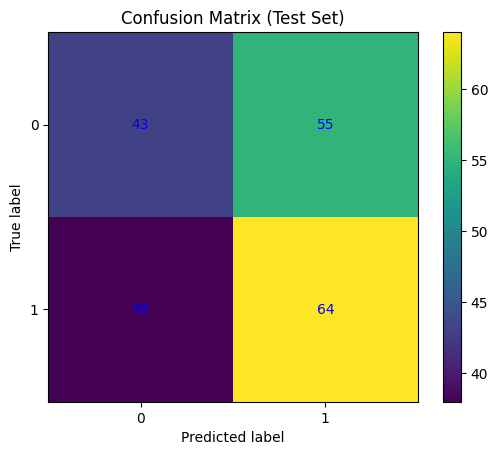

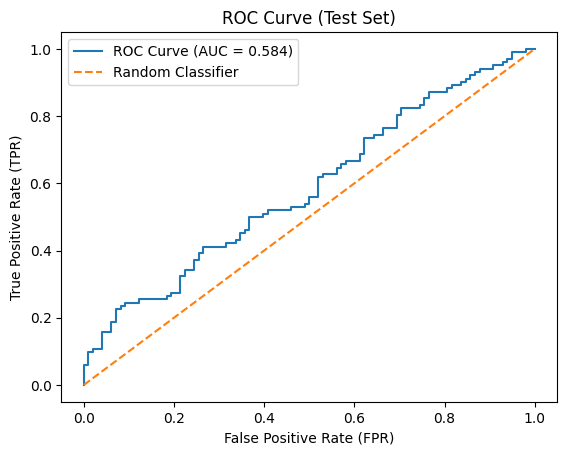

Unique test labels: [0 1]
Classification Report (Test Set):
              precision    recall  f1-score   support

     Class 0       0.53      0.44      0.48        98
     Class 1       0.54      0.63      0.58       102

    accuracy                           0.54       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.53      0.54      0.53       200

Classification Report (Train Set):
              precision    recall  f1-score   support

     Class 0       0.52      0.42      0.46       392
     Class 1       0.53      0.62      0.57       408

    accuracy                           0.52       800
   macro avg       0.52      0.52      0.52       800
weighted avg       0.52      0.52      0.52       800



In [52]:
# -------------------------------------------------
# Step 5: Visualization & Interpretation
# Confusion Matrix, ROC Curve (AUC), Classification Report
# (Assumes you already have: model, criterion, X_train_tensor, y_train_tensor,
#  X_test_tensor, y_test_tensor from earlier steps)
# -------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report


# -------------------------------------------------
# 1) Retrain the model with L2 regularization (weight decay)
# -------------------------------------------------
optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=0.01)
num_epochs = 1000

for epoch in range(1, num_epochs + 1):
    model.train()                 # training mode (enables dropout/bn if present)
    optimizer.zero_grad()         # clear old gradients

    probs = model(X_train_tensor) # forward pass -> predicted probabilities
    loss = criterion(probs, y_train_tensor)  # BCELoss on probabilities vs labels

    loss.backward()               # backprop -> compute gradients
    optimizer.step()              # update weights

    if epoch % 100 == 0:
        print(f"Epoch [{epoch}/{num_epochs}] - Loss: {loss.item():.6f}")


# -------------------------------------------------
# 2) Evaluate the model: get probabilities and class predictions
# -------------------------------------------------
model.eval()  # evaluation mode
with torch.no_grad():  # no gradient tracking during evaluation
    train_probs = model(X_train_tensor).cpu().numpy().ravel()
    test_probs  = model(X_test_tensor).cpu().numpy().ravel()

# Convert probabilities to predicted classes using 0.5 threshold
train_preds = (train_probs >= 0.5).astype(int)
test_preds  = (test_probs >= 0.5).astype(int)

# True labels as NumPy (ensure shape is (N,))
y_train_true = y_train_tensor.cpu().numpy().ravel().astype(int)
y_test_true  = y_test_tensor.cpu().numpy().ravel().astype(int)

print(classification_report(
    y_test_true, test_preds,
    labels=[0, 1],
    target_names=["Class 0", "Class 1"],
    zero_division=0
))

# -------------------------------------------------
# 3) Confusion Matrix (Test Set)
# TP, TN, FP, FN breakdown of predictions vs actual labels
# -------------------------------------------------
cm = confusion_matrix(y_test_true, test_preds, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
# Create a Figure (overall canvas) and an Axes (plotting area) object
# to allow explicit control over the plot and its annotations
fig, ax = plt.subplots()
disp.plot(ax=ax, values_format="d")

# Force all annotation text to be black
for text in ax.texts:
    text.set_color("blue")

plt.title("Confusion Matrix (Test Set)")
plt.show()


# -------------------------------------------------
# 4) ROC Curve + AUC (Test Set)
# ROC plots TPR vs FPR for all thresholds; AUC summarizes performance
# -------------------------------------------------
# ROC Curve only makes sense if BOTH classes are present in y_test_true
if len(np.unique(y_test_true)) == 2:
    fpr, tpr, _ = roc_curve(y_test_true, test_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve (Test Set)")
    plt.legend()
    plt.show()
else:
    print("ROC/AUC skipped: test set contains only one class.")

print("Unique test labels:", np.unique(y_test_true))



# -------------------------------------------------
# 5) Classification Report (Test Set)
# Includes precision, recall, F1-score, support
# -------------------------------------------------
print("Classification Report (Test Set):")
print(classification_report(y_test_true, test_preds, target_names=["Class 0", "Class 1"]))


# -------------------------------------------------
# (Optional) Also print training report to compare overfitting vs generalization
# -------------------------------------------------
print("Classification Report (Train Set):")
print(classification_report(y_train_true, train_preds, target_names=["Class 0", "Class 1"]))




Double-click <b>here</b> for the Hint.
<!-- 

#Change the name of variables as per your code
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools

# Visualize the confusion matrix
#Change the variable names as used in your code
y_pred_test_labels = (y_pred_test > 0.5).float()
cm = confusion_matrix(y_test, y_pred_test_labels)

plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = range(2)
plt.xticks(tick_marks, ['Loss', 'Win'], rotation=45)
plt.yticks(tick_marks, ['Loss', 'Win'])

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred_test_labels, target_names=['Loss', 'Win']))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()
-->


### Step 6: Model Saving and Loading  

#### Task 6: Save and load the trained model.  

This task demonstrates the techniques to persist a trained model using `torch.save` and reload it using `torch.load`. Evaluating the loaded model ensures that it retains its performance, making it practical for deployment in real-world applications.  

1. Saving the Model:
- Save the model's learned weights and biases using torch.save().( e.g. , torch.save(model.state_dict(), 'your_model_name.pth'))
- Saving only the state dictionary (model parameters) is preferred because it’s more flexible and efficient than saving the entire model object.

2. Loading the Model:
- Create a new model instance (e.g., `model = LogisticRegressionModel()`) and load the saved parameters. ( e.g. , `model.load_state_dict(torch.load('your_model_name.pth'))`)`.

3. Evaluating the Loaded Model:
   - After loading, set the model to evaluation mode by calling `model.eval()
   - After loading the model, evaluate it again on the test dataset to make sure it performs similarly to when it was first trained..Now evaluate it on the test data.
   - Use `torch.no_grad()` to ensure that no gradients are computed.

#### Exercise 6:  

Write code to save the trained model and reload it. Ensure the loaded model performs consistently by evaluating it on the test dataset.  


In [ ]:
# -------------------------------------------------
# Step 6: Model Saving and Loading
# -------------------------------------------------

# -----------------------------
# 1) Save the trained model
# -----------------------------
# Save only the model's learned parameters (state_dict).
# This is preferred over saving the entire model object.
model_path = "logistic_regression_lol.pth"
torch.save(model.state_dict(), model_path)

print(f"Model saved to {model_path}")


# -----------------------------
# 2) Load the model into a new instance
# -----------------------------
# Create a new model instance with the same architecture
loaded_model = LogisticRegressionModel(input_dim=X_train_tensor.shape[1])

# Load the saved parameters into the new model
loaded_model.load_state_dict(torch.load(model_path))

# Set the model to evaluation mode
loaded_model.eval()

print("Model loaded successfully.")


# -----------------------------
# 3) Evaluate the loaded model
# -----------------------------
# Ensure no gradients are computed during evaluation
with torch.no_grad():
    # Get predicted probabilities on the test set
    test_probs_loaded = loaded_model(X_test_tensor)

    # Convert probabilities to binary predictions using 0.5 threshold
    test_preds_loaded = (test_probs_loaded >= 0.5).float()

    # Compute test accuracy
    test_acc_loaded = (
        test_preds_loaded == y_test_tensor
    ).float().mean().item()

# Print test accuracy of the loaded model
print(f"Test Accuracy (Loaded Model): {test_acc_loaded * 100:.2f}%")


### Step 7: Hyperparameter Tuning  

#### Task 7: Perform hyperparameter tuning to find the best learning rate.  

By testing different learning rates, you will identify the optimal rate that provides the best test accuracy. This fine-tuning is crucial for enhancing model performance . 
1. Define Learning Rates:
   - Choose these learning rates to test ,[0.01, 0.05, 0.1]

2. Reinitialize the Model for Each Learning Rate:
  - For each learning rate, you’ll need to reinitialize the model and optimizer e.g.(`torch.optim.SGD(model.parameters(), lr=lr)`).
   - Each new learning rate requires reinitializing the model since the optimizer and its parameters are linked to the learning rate.

3. Train the Model for Each Learning Rate:
  - Train the model for a fixed number of epochs (e.g., 50 or 100 epochs) for each learning rate, and compute the accuracy on the test set.
  - Track the test accuracy for each learning rate and identify which one yields the best performance.

4. Evaluate and Compare:
  - After training with each learning rate, compare the test accuracy for each configuration.
   - Report the learning rate that gives the highest test accuracy

#### Exercise 7:  

Perform hyperparameter tuning to find the best learning rate. Retrain the model for each learning rate and evaluate its performance to identify the optimal rate.  


In [ ]:
# -------------------------------------------------
# Step 7: Hyperparameter Tuning (Learning Rate)
# Tests learning rates: [0.01, 0.05, 0.1]
# Reinitializes model + optimizer for each LR
# Trains for a fixed number of epochs and evaluates test accuracy
# -------------------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim

# Learning rates to test
learning_rates = [0.01, 0.05, 0.1]

# Fixed number of epochs for each run (use 50 or 100 as requested)
tune_epochs = 100

# Track results
results = {}  # lr -> test_accuracy

for lr in learning_rates:
    # -----------------------------
    # Reinitialize model (fresh weights each LR)
    # -----------------------------
    input_dim = X_train_tensor.shape[1]
    model = LogisticRegressionModel(input_dim)

    # Loss function (binary cross entropy)
    criterion = nn.BCELoss()

    # Optimizer for this learning rate
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # -----------------------------
    # Train for fixed epochs
    # -----------------------------
    for epoch in range(1, tune_epochs + 1):
        model.train()
        optimizer.zero_grad()

        probs = model(X_train_tensor)
        loss = criterion(probs, y_train_tensor)

        loss.backward()
        optimizer.step()

    # -----------------------------
    # Evaluate on test set
    # -----------------------------
    model.eval()
    with torch.no_grad():
        test_probs = model(X_test_tensor)
        test_preds = (test_probs >= 0.5).float()

        test_acc = (test_preds == y_test_tensor).float().mean().item()

    # Store and print result for this LR
    results[lr] = test_acc
    print(f"Learning Rate: {lr:.2f} -> Test Accuracy: {test_acc * 100:.2f}%")

# -----------------------------
# Identify best learning rate
# -----------------------------
best_lr = max(results, key=results.get)
best_acc = results[best_lr]

print("\nBest Learning Rate:")
print(f"lr = {best_lr} with Test Accuracy = {best_acc * 100:.2f}%")




### Step 8: Feature Importance  

#### Task 8: Evaluate feature importance to understand the impact of each feature on the prediction.  

The code to evaluate feature importance to understand the impact of each feature on the prediction.

 1.Extracting Model Weights:
  - The weights of the logistic regression model represent the importance of each feature in making predictions. These weights are stored in the model's linear layer (`model.linear.weight`).
 - You can extract the weights using `model.linear.weight.data.numpy()` and flatten the resulting tensor to get a 1D array of feature importances.

2.Creating a DataFrame:
 - Create a pandas DataFrame with two columns: one for the feature names and the other for their corresponding importance values (i.e., the learned weights).
 - Ensure the features are aligned with their names in your dataset (e.g., `X_train.columns).

3. Sorting and Plotting Feature Importance:
  - Sort the features based on the absolute value of their importance (weights) to identify the most impactful features.
  - Use a bar plot (via `matplotlib`) to visualize the sorted feature importances, with the feature names on the y-axis and importance values on the x-axis.

4. Interpreting the Results:
  - Larger absolute weights indicate more influential features. Positive weights suggest a positive correlation with the outcome (likely to predict the positive class), while negative weights suggest the opposite.

#### Exercise 8:  

Evaluate feature importance by extracting the weights of the linear layer and creating a DataFrame to display the importance of each feature. Visualize the feature importance using a bar plot.  


In [ ]:
# -------------------------------------------------
# Step 8: Feature Importance (Logistic Regression Weights)
# - Extract learned weights from the linear layer
# - Pair weights with feature names in a DataFrame
# - Sort by absolute weight magnitude
# - Plot feature importance as a horizontal bar chart
# -------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Extract model weights
# -----------------------------
# model.linear.weight has shape (1, num_features) for binary logistic regression
weights = model.linear.weight.detach().cpu().numpy().flatten()

# -----------------------------
# 2) Get feature names (MUST match the columns used to build X)
# -----------------------------
# If you built X with: X = df.drop(columns=["win"])
# then your feature names are:
feature_names = df.drop(columns=["win"]).columns

# Safety check: make sure names align with weights
assert len(feature_names) == len(weights), "Feature names and weights length mismatch."

# -----------------------------
# 3) Create a DataFrame of importances
# -----------------------------
importance_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights
})

# Add absolute weight for ranking (magnitude = impact)
importance_df["abs_weight"] = importance_df["weight"].abs()

# Sort by magnitude (largest impact first)
importance_df = importance_df.sort_values("abs_weight", ascending=False)

print("Top features by absolute weight:")
print(importance_df[["feature", "weight"]].head(10))

# -----------------------------
# 4) Plot feature importance (top N for readability)
# -----------------------------
top_n = 10  # change to show more/less
plot_df = importance_df.head(top_n).sort_values("weight")  # sort for nicer bar ordering

plt.figure()
plt.barh(plot_df["feature"], plot_df["weight"])
plt.xlabel("Weight (Feature Importance)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Feature Importances (Logistic Regression Weights)")
plt.show()

# -----------------------------
# Interpretation tip:
# - Larger |weight| => more influence on the prediction
# - Positive weight => pushes prediction toward class 1 (win=1)
# - Negative weight => pushes prediction toward class 0 (win=0)
# -----------------------------





Double-click <b>here</b> for the Hint
<!-- 
#Use the following code to extract the weight and create dataframe
#Change the name of variables per your code

Extract the weights of the linear layer:
weights = model.linear.weight.data.numpy().flatten()
features = X.columns
Create a DataFrame for feature importance:
feature_importance = pd.DataFrame({'Feature': features, 'Importance': weights})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)
Plot feature importance plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()
-->


#### Conclusion:  

Congratulations on completing the project! In this final project, you built a logistic regression model to predict the outcomes of League of Legends matches based on various in-game statistics. This comprehensive project involved several key steps, including data loading and preprocessing, model implementation, training, optimization, evaluation, visualization, model saving and loading, hyperparameter tuning, and feature importance analysis. This project provided hands-on experience with the complete workflow of developing a machine learning model for binary classification tasks using PyTorch.

© Copyright IBM Corporation. All rights reserved.
